# Medical Insurance Cost Prediction using Multiple Linear Regression

**Objective:** Estimate a customer's medical insurance charges from their personal and health-related information using a Multiple Linear Regression model.

**Dataset:** [Medical Cost Personal Insurance Dataset (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## Task 1: Data Understanding

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (1338, 7)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Feature identification**

| Type | Columns |
|---|---|
| Numerical features | `age`, `bmi`, `children` |
| Categorical features | `sex`, `smoker`, `region` |
| Target variable | `charges` |

## Task 2: Data Preprocessing

**Check for missing values** — done above; the dataset has 0 missing values across all 7 columns, so no imputation is needed.

**Encode categorical variables**
- `sex`, `smoker` are binary → mapped to 0/1
- `region` has 4 nominal categories → one-hot encoded (with `drop_first=True` to avoid the dummy-variable trap)

In [12]:
df_enc = df.copy()
df_enc['sex'] = df_enc['sex'].map({'female': 0, 'male': 1})
df_enc['smoker'] = df_enc['smoker'].map({'no': 0, 'yes': 1})
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)
df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


**Train/test split — 80% train, 20% test**

In [14]:
from sklearn.model_selection import train_test_split

X = df_enc.drop('charges', axis=1)
y = df_enc['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 1070  Test size: 268


## Task 3: Model Development

Features: `age`, `sex`, `bmi`, `children`, `smoker`, `region` (encoded) → Target: `charges`

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef_table = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
coef_table

,feature,coefficient
0,age,256.975706
1,sex,-18.591692
2,bmi,337.092552
3,children,425.278784
4,smoker,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## Task 4: Model Evaluation

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

MAE:  4181.19
MSE:  33596915.85
RMSE: 5796.28
R2:   0.7836


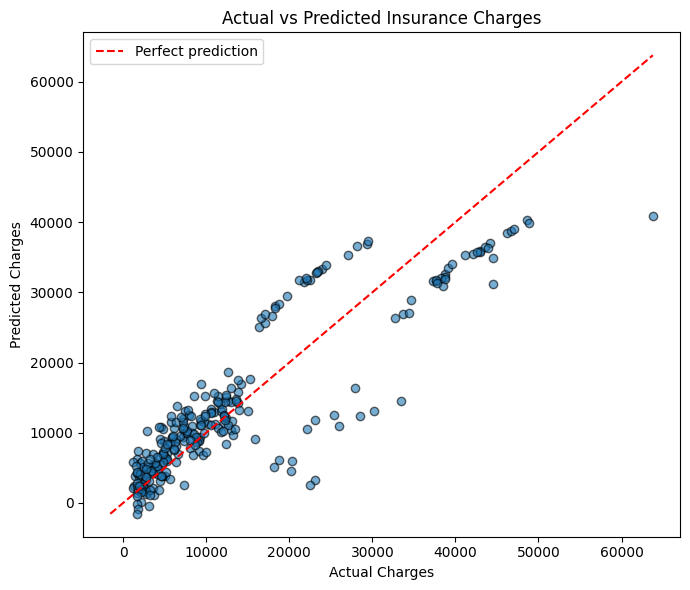

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

**Observations**
1. `smoker` is the dominant driver of predicted charges, having the largest coefficient (+23,651).
2. The model explains about 78% of the variance in charges (R² = 0.78).
3. `sex` and `region` have small coefficients, contributing less to predictions than `age`, `bmi`, `children`, and `smoker`.

## Task 5: Conclusion
The Multiple Linear Regression model predicts medical insurance charges with an R² of 0.78 and a Mean Absolute Error of $4,181.

**Key Findings:**
- The model explains 78% of the variance in insurance charges.
- The most significant factor affecting insurance charges is smoking status, which drastically increases the predicted charges.
- BMI, age, and number of children are also important, while sex and region have a negligible impact.

**Limitation of Linear Regression:**
A major limitation of Linear Regression for this problem is its inability to capture complex, non-linear interaction effects. For instance, the data indicates that the combination of smoking and high BMI increases charges much more than the sum of their individual effects. Because a basic linear model only assumes additive relationships, it struggles to accurately predict charges for high-BMI smokers, resulting in larger prediction errors for those specific individuals.